# Introduction

I want to use `osmnx` to get the

1. Roads
2. Pedestrian
3. Cycling Paths

For Singapore (Woodlands and Sembawang $\approx\text{29 km}^2$) and the city of Delft  ($26 \text{km}^2$)

Delft Intersections to consider
1. 51.99076, 4.35784
2. 52.0006, 4.43847
3. 52.00353, 4.35678
4. 52.00026, 4.33925 (Mollenburt)
5. 51.9924, 4.3554 (Single lane intersection)
6. 51.98905, 4.35883 (Intersection 1)
7. 51.99072, 4.3578 (Intersection 2)
8. 51.99646, 4.38101 (T-Junction)


network_type (str) – {“all”, “all_public”, “bike”, “drive”, “drive_service”, “walk”} What type of street network to retrieve if custom_filter is None.

# TODOs:
- Build router that can take in 5 O-D and plot path, different colour for each O-D pair, and different line style to represent bike/ped versus cars; to show the diff in overlaps between car and bike travel.
- Reduce the rendering lag/latency in maps with big geodata
  - [Blog post on reducing Folium HTML output map size](https://andrewpwheeler.com/2024/08/04/reducing-folium-map-sizes/)
  - [Stack: GeoJSON -> TopoJOSN](https://gis.stackexchange.com/questions/178876/speeding-up-large-geojsons-in-leaflet-maps)
  - [Stack: Installing TopoJSON](https://gis.stackexchange.com/questions/45138/convert-geojson-to-topojson)
  - [Medium: Converting large GeoJSON to TopoJSON](https://medium.com/tech-carnot/topojson-based-choropleth-visualization-using-folium-471113fa5964)
  - [TopoJSON official doc](https://mattijn.github.io/topojson/example/input-types.html#geodataframe-or-geoseries)


In [ ]:
# Import packages
import networkx as nx
import osmnx as ox
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import folium
from folium.plugins import MousePosition
import shapely
import tomllib
from src import preprocessing
import numpy as np
import topojson as tp
# Load config file
with open("config.toml", "rb") as f:
    CONFIG = tomllib.load(f)

%load_ext autoreload
%autoreload 2

## Load Data Files

In [2]:
# Load all the polyline geodataframes
wlds_semb_road_edges_gdf = preprocessing.load_pickle_file("./data/pickled/wlds_semb_road_edges_gdf.pkl")
wlds_semb_bike_edges_gdf = preprocessing.load_pickle_file("./data/pickled/wlds_semb_bike_edges_gdf.pkl")
delft_road_edges_gdf = preprocessing.load_pickle_file("./data/pickled/delft_road_edges_gdf.pkl")
delft_bike_edges_gdf = preprocessing.load_pickle_file("./data/pickled/delft_bike_edges_gdf.pkl")

road_gdfs = [wlds_semb_road_edges_gdf, delft_road_edges_gdf]
bike_ped_gdfs = [wlds_semb_bike_edges_gdf, delft_bike_edges_gdf]

for road_gdf, bike_ped_gdf in zip(road_gdfs, bike_ped_gdfs):
    road_gdf["tooltip_label"] = "Roads"
    bike_ped_gdf["tooltip_label"] = "Bike Path / Sidewalk"

## Create Maps

### Singapore

In [43]:
# Merged multiline map_sg
map_sg = folium.Map(location=[1.37529, 103.80465], tiles="CartoDB Positron", zoom_start=11.5)
MousePosition().add_to(map_sg)

tooltip = folium.GeoJsonTooltip(
    fields=['tooltip_label'],
    aliases=["Network Type:"]
)

folium.GeoJson(wlds_semb_road_edges_gdf,
               tooltip=tooltip,
               style_function=lambda x : {'color': CONFIG["network_colors"]["roads"],
                                          "weight": CONFIG["network_weights"]["roads"]}
               ).add_to(map_sg)

tooltip = folium.GeoJsonTooltip(
    fields=['tooltip_label'],
    aliases=["Network Type:"]
)

folium.GeoJson(wlds_semb_bike_edges_gdf,
               tooltip=tooltip,
               style_function=lambda x : {'color': CONFIG["network_colors"]['bike_ped'],
                                          "weight": CONFIG["network_weights"]["bike_ped"]}
               ).add_to(map_sg)

folium.LayerControl().add_to(map_sg)

map_sg.save("./maps/overlay_singapore.html")


### Delft

In [18]:
delft_road_edges_gdf.head(2)

,u,v,key,osmid,highway,lanes,maxspeed,name,oneway,reversed,length,geometry,tunnel,bridge,access,ref,width,junction,tooltip_label
0,27082148,44839614,0,48688450,tertiary,2,50,Delfgauwseweg,False,False,141.011455,"LINESTRING (4.37897 52.0084, 4.37721 52.00906)",NaN,NaN,NaN,NaN,NaN,NaN,Roads
1,27082148,44835830,0,7537370,residential,NaN,30,Spiekmanstraat,False,True,39.821403,"LINESTRING (4.37897 52.0084, 4.3789 52.00834, ...",NaN,NaN,NaN,NaN,NaN,NaN,Roads


In [44]:
map_delft = folium.Map(location=[52.01, 4.36], tiles="CartoDB Positron", zoom_start=11.5)
MousePosition().add_to(map_delft)

tooltip = folium.GeoJsonTooltip(
    fields=['tooltip_label'],
    aliases=["Network Type:"]
)

folium.GeoJson(delft_road_edges_gdf,
               tooltip=tooltip,
               style_function=lambda x : {'color': CONFIG["network_colors"]["roads"],
                                          "weight": CONFIG["network_weights"]["roads"]}
               ).add_to(map_delft)

tooltip = folium.GeoJsonTooltip(
    fields=['tooltip_label'],
    aliases=["Network Type:"]
)

folium.GeoJson(delft_bike_edges_gdf,
               tooltip=tooltip,
               style_function=lambda x : {'color': CONFIG["network_colors"]['bike_ped'],
                                          "weight": CONFIG["network_weights"]["bike_ped"]}
               ).add_to(map_delft)

folium.LayerControl().add_to(map_delft)

map_delft.save("./maps/overlay_delft.html")

## Singapore Network Difference

In [26]:
wlds_semb_bike_edges_gdf.shape

(11499, 19)

In [25]:
wlds_semb_road_edges_gdf.shape

(2595, 18)

In [24]:
sg_roads_bike_ped_gdf = pd.concat([wlds_semb_bike_edges_gdf, wlds_semb_road_edges_gdf])
sg_roads_bike_ped_gdf.shape

(14094, 20)

In [29]:
sg_roads_bike_ped_gdf['tooltip_label'].unique()[1]

'Roads'

In [37]:
folium.GeoJson(sg_roads_bike_ped_gdf)

In [30]:
CONFIG

{'network_colors': {'roads': 'red', 'bike_ped': 'green'},
 'network_weights': {'roads': 5, 'bike_ped': 2}}

In [40]:
wlds_semb_bike_edges_gdf.head()

,u,v,key,osmid,highway,lanes,maxspeed,name,oneway,reversed,length,geometry,access,service,bridge,junction,tunnel,width,tooltip_label
0,236740571,4474612146,0,"[652576984, 652576986, 641079613, 642481534, 6...",primary,"[3, 2]",50,Woodlands Centre Road,True,False,259.404195,"LINESTRING (103.76869 1.44104, 103.76878 1.441...",NaN,NaN,NaN,NaN,NaN,NaN,Bike Path / Sidewalk
1,244316787,8106010509,0,"[632107408, 632107409]",primary,"[4, 3]",60,Sembawang Road,True,False,27.040284,"LINESTRING (103.82582 1.43542, 103.82579 1.435...",NaN,NaN,NaN,NaN,NaN,NaN,Bike Path / Sidewalk
2,244316825,244316826,0,536626242,primary,4,60,Sembawang Road,True,False,14.833640,"LINESTRING (103.82357 1.44483, 103.82354 1.44496)",NaN,NaN,NaN,NaN,NaN,NaN,Bike Path / Sidewalk
3,244316825,244963755,0,480461588,primary,3,70,Sembawang Avenue,True,False,44.599131,"LINESTRING (103.82357 1.44483, 103.82349 1.444...",NaN,NaN,NaN,NaN,NaN,NaN,Bike Path / Sidewalk
4,244316826,244316866,0,75351732,primary,4,60,Sembawang Road,True,False,14.073225,"LINESTRING (103.82354 1.44496, 103.82364 1.44503)",NaN,NaN,NaN,NaN,NaN,NaN,Bike Path / Sidewalk


In [40]:
# Get difference maps
test_clip_gdf = gpd.clip(gdf=wlds_semb_road_edges_gdf, mask=wlds_semb_bike_edges_gdf)
# sg_difference_gdf = difference_series_to_gpd(sg_network_diff_series)
# # preprocessing.pickle_object(sg_difference_gdf, "./data/pickled/sg_difference_gdf.pkl")
test_clip_gdf = test_clip_gdf[
    (test_clip_gdf.geometry.notnull()) & 
    (~test_clip_gdf.geometry.is_empty)
]
test_clip_gdf['tooltip_label'] = 'Network Difference'
point_types = [shapely.geometry.multipoint.MultiPoint, shapely.geometry.point.Point, shapely.geometry.collection.GeometryCollection]
clipped_gdf = test_clip_gdf[test_clip_gdf["geometry"].apply(lambda geometry: type(geometry) not in point_types)]

In [41]:
np.unique([str(type(geometry)) for geometry in clipped_gdf["geometry"]])

array(["<class 'shapely.geometry.linestring.LineString'>",
       "<class 'shapely.geometry.multilinestring.MultiLineString'>"],
      dtype='<U58')

In [4]:
# Side-by-side
# Left: map_sg_diff 
# Right: map_sg
sg_difference_gdf = preprocessing.load_pickle_file("./data/pickled/sg_difference_gdf.pkl").to_crs(epsg=3414)

tooltip_right = folium.GeoJsonTooltip(
    fields=['u', 'v', 'key'],
)

# Create map
sbs_sg_map = folium.plugins.DualMap(location=[1.37529, 103.80465], tiles="CartoDB Positron", zoom_start=11.5)
SMOOTH_FACTOR = 5

tile = folium.TileLayer(
        tiles = 'https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
        attr = 'Esri',
        name = 'Esri Satellite',
        overlay = False,
        control = True
       ).add_to(sbs_sg_map.m1)

folium.GeoJson(wlds_semb_road_edges_gdf,
                name="Roads Network",
                ).add_to(sbs_sg_map.m1)

folium.GeoJson(wlds_semb_bike_edges_gdf,
               style_function=lambda feature: {'color': CONFIG["network_colors"]['roads'] if "Roads" in feature["properties"]["tooltip_label"]
                                            else CONFIG["network_colors"]['bike_ped'],
                                          "weight": CONFIG["network_weights"]['roads'] if "Roads" in feature["properties"]["tooltip_label"]
                                            else CONFIG["network_weights"]['bike_ped']},
               name="Bike/Pedestrian Network",
               tooltip=tooltip_right
               ).add_to(sbs_sg_map.m2)

folium.GeoJson(wlds_semb_road_edges_gdf,
               style_function=lambda feature: {'color': CONFIG["network_colors"]['roads'] if "Roads" in feature["properties"]["tooltip_label"]
                                            else CONFIG["network_colors"]['bike_ped'],
                                          "weight": CONFIG["network_weights"]['roads'] if "Roads" in feature["properties"]["tooltip_label"]
                                            else CONFIG["network_weights"]['bike_ped']},
               name="Roads Network" 
               ).add_to(sbs_sg_map.m2)

# sbs = folium.plugins.SideBySideLayers(layer_left=layer_left, layer_right=layer_right)
folium.LayerControl(collapsed=False).add_to(sbs_sg_map)
# layer_left.add_to(sbs_sg_map)
# layer_right.add_to(sbs_sg_map)

sbs_sg_map.save("./maps/sbs_sg.html")

# Get Data Files

In [ ]:
wlds_semb_polygon = preprocessing.load_pickle_file('./data/pickled/wlds_semb_polygon.pkl')
# Get Woodlands-Sembawang Road Network
wlds_semb_road_nodes_gdf, wlds_semb_road_edges_gdf = preprocessing.polygon_to_gdf(wlds_semb_polygon, network_type="drive")
wlds_semb_road_line_strings = preprocessing.polygon_to_line_string(wlds_semb_polygon, "drive")
# Get Woodlands-Sembawang Bike Network
wlds_semb_bike_nodes_gdf, wlds_semb_bike_edges_gdf = preprocessing.polygon_to_gdf(wlds_semb_polygon, network_type="bike")
wlds_semb_bike_line_strings = preprocessing.polygon_to_line_string(wlds_semb_polygon, "bike")

DELFT_SEARCH_TERMS = "Delft, Netherlands"
# Get Delft Road Network
delft_road_nodes_gdf, delft_road_edges_gdf = preprocessing.place_to_gdf(DELFT_SEARCH_TERMS, "drive")
delft_road_line_strings = preprocessing.place_to_line_string(DELFT_SEARCH_TERMS, "drive")
# Get Delft Bike Network
delft_bike_nodes_gdf, delft_bike_edges_gdf = preprocessing.place_to_gdf(DELFT_SEARCH_TERMS, "bike")
delft_bike_line_strings = preprocessing.place_to_line_string(DELFT_SEARCH_TERMS, "bike")

# # Uncomment to overwrite pickle: 
# # Pickle all gdfs (2 per network, so 8 total)
# preprocessing.pickle_object(wlds_semb_road_nodes_gdf, "./data/pickled/wlds_semb_road_nodes_gdf.pkl")
# preprocessing.pickle_object(wlds_semb_road_edges_gdf, "./data/pickled/wlds_semb_road_edges_gdf.pkl")

# preprocessing.pickle_object(wlds_semb_bike_nodes_gdf, "./data/pickled/wlds_semb_bike_nodes_gdf.pkl")
# preprocessing.pickle_object(wlds_semb_bike_edges_gdf, "./data/pickled/wlds_semb_bike_edges_gdf.pkl")

# preprocessing.pickle_object(delft_road_nodes_gdf, "./data/pickled/delft_road_nodes_gdf.pkl")
# preprocessing.pickle_object(delft_road_edges_gdf, "./data/pickled/delft_road_edges_gdf.pkl")

# preprocessing.pickle_object(delft_bike_nodes_gdf, "./data/pickled/delft_bike_nodes_gdf.pkl")
# preprocessing.pickle_object(delft_bike_edges_gdf, "./data/pickled/delft_bike_edges_gdf.pkl")

# # Pickle all the line strings
# preprocessing.pickle_object(wlds_semb_road_line_strings, "./data/pickled/wlds_semb_road_line_strings.pkl")
# preprocessing.pickle_object(wlds_semb_bike_line_strings, "./data/pickled/wlds_semb_bike_line_strings.pkl")
# preprocessing.pickle_object(delft_road_line_strings, "./data/pickled/delft_road_line_strings.pkl")
# preprocessing.pickle_object(delft_bike_line_strings, "./data/pickled/delft_bike_line_strings.pkl")

In [24]:
type(wlds_semb_bike_edges_gdf['geometry'])

geopandas.geoseries.GeoSeries

In [3]:
def difference_series_to_gpd(diff_series):
    difference_gdf = gpd.GeoDataFrame(sg_network_diff_series)
    difference_gdf = difference_gdf.rename(columns={0: 'geometry'})
    difference_gdf = difference_gdf.set_geometry("geometry")
    difference_gdf = difference_gdf[
        (difference_gdf.geometry.notnull()) & 
        (~difference_gdf.geometry.is_empty)
    ]
    difference_gdf['tooltip_label'] = 'Network Difference'
    return difference_gdf

In [7]:
# Get difference maps
sg_network_diff_series= wlds_semb_bike_edges_gdf['geometry'].difference(wlds_semb_road_edges_gdf['geometry'])
sg_difference_gdf = difference_series_to_gpd(sg_network_diff_series)
# preprocessing.pickle_object(sg_difference_gdf, "./data/pickled/sg_difference_gdf.pkl")

/tmp/ipykernel_26867/1557357202.py:2: UserWarning: The indices of the left and right GeoSeries' are not equal, and therefore they will be aligned (reordering and/or introducing missing values) before executing the operation. If this alignment is the desired behaviour, you can silence this warning by passing 'align=True'. If you don't want alignment and protect yourself of accidentally aligning, you can pass 'align=False'.
  sg_network_diff_series= wlds_semb_bike_edges_gdf['geometry'].difference(wlds_semb_road_edges_gdf['geometry'])
/home/nicholas/miniconda3/envs/ox/lib/python3.14/site-packages/geopandas/geoseries.py:906: UserWarning: GeoSeries.notna() previously returned False for both missing (None) and empty geometries. Now, it only returns False for missing values. Since the calling GeoSeries contains empty geometries, the result has changed compared to previous versions of GeoPandas.
Given a GeoSeries 's', you can use '~s.is_empty & s.notna()' to get back the old behaviour.

To fur

In [18]:
sg_difference_gdf = difference_series_to_gpd(sg_network_diff_series)
sg_difference_gdf.head(2)

# Merged multiline map
map_sg_diff = folium.Map(location=[1.37529, 103.80465], tiles="CartoDB Positron", zoom_start=11.5)
MousePosition().add_to(map_sg_diff)

tooltip = folium.GeoJsonTooltip(
    fields=['tooltip_label'],
    aliases=["Network Type:"]
)

folium.GeoJson(sg_difference_gdf,
               tooltip=tooltip,
               ).add_to(map_sg_diff)


map_sg_diff.save("./maps/diff_sg.html")

/home/nicholas/miniconda3/envs/ox/lib/python3.14/site-packages/geopandas/geoseries.py:906: UserWarning: GeoSeries.notna() previously returned False for both missing (None) and empty geometries. Now, it only returns False for missing values. Since the calling GeoSeries contains empty geometries, the result has changed compared to previous versions of GeoPandas.
Given a GeoSeries 's', you can use '~s.is_empty & s.notna()' to get back the old behaviour.

To further ignore this warning, you can do: 
import warnings; warnings.filterwarnings('ignore', 'GeoSeries.notna', UserWarning)
  return self.notna()


# Singapore (Woodlands + Sembawang)

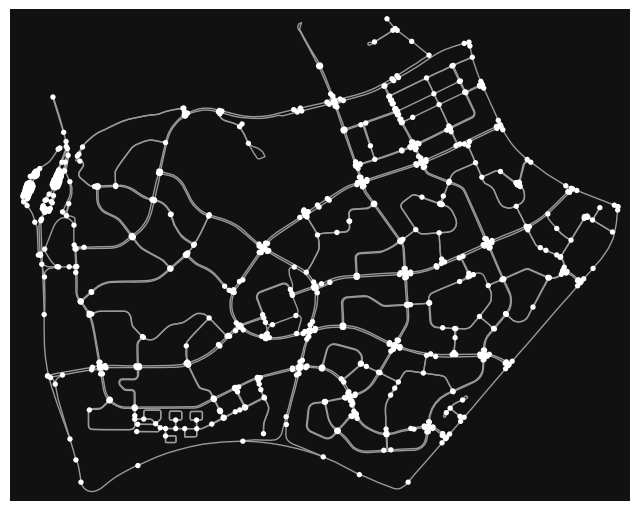

In [33]:
# download/model a street network for some city then visualize it
G_sg_woodlands_roads = ox.graph.graph_from_place("Woodlands, Singapore", network_type="drive")
fig, ax = ox.plot.plot_graph(G_sg_woodlands_roads)

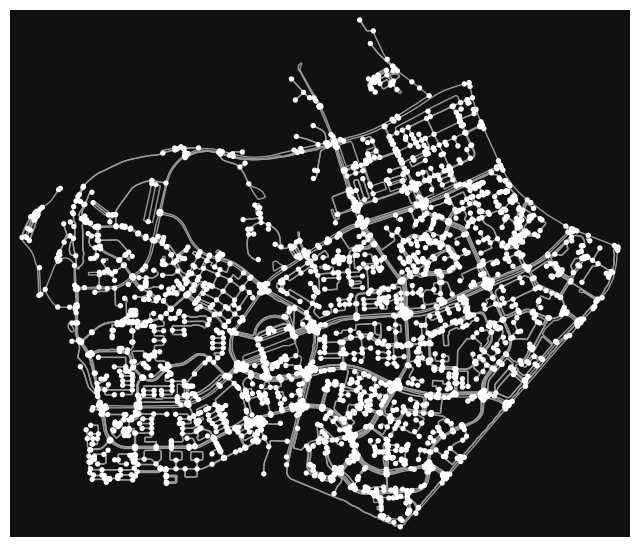

In [41]:
# download/model a street network for some city then visualize it
G_sg_woodlands_bike_ped = ox.graph.graph_from_place("Woodlands, Singapore", network_type="bike")
fig, ax = ox.plot.plot_graph(G_sg_woodlands_bike_ped)

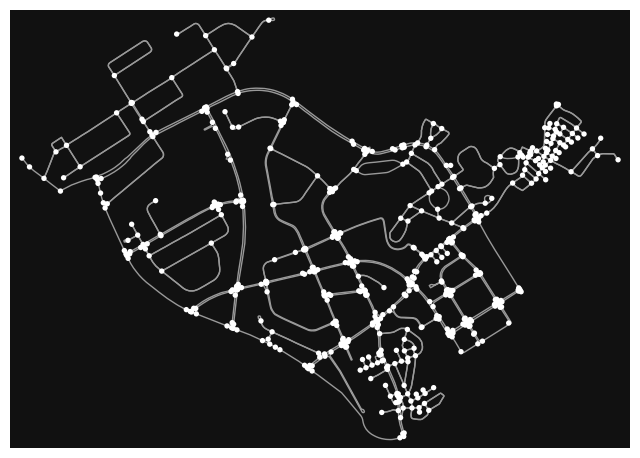

In [34]:
# download/model a street network for some city then visualize it
G_sg_sembawang_roads = ox.graph.graph_from_place("Sembawang, Singapore", network_type="drive")
fig, ax = ox.plot.plot_graph(G_sg_sembawang_roads)

# Get Woodlands-Sembawang Bounding Polygon

In [4]:
# Read subzone geojson
sg_subzone_gdf = gpd.read_file("./data/raw/MasterPlan2019SubzoneBoundaryNoSeaGEOJSON.geojson")
sg_subzone_gdf.head(2)

,OBJECTID,SUBZONE_NO,SUBZONE_N,SUBZONE_C,CA_IND,PLN_AREA_N,PLN_AREA_C,REGION_N,REGION_C,INC_CRC,FMEL_UPD_D,SHAPE.AREA,SHAPE.LEN,geometry
0,676,12,DEPOT ROAD,BMSZ12,N,BUKIT MERAH,BM,CENTRAL REGION,CR,C22DED671DE2A940,20191223152313,442297.509556,4281.667289,"POLYGON ((103.81454 1.28239, 103.81427 1.28253..."
1,677,2,BUKIT MERAH,BMSZ02,N,BUKIT MERAH,BM,CENTRAL REGION,CR,085EF219A5A1AEAD,20191223152313,411722.830243,3074.963234,"POLYGON ((103.82209 1.28049, 103.82209 1.28057..."


In [5]:
planning_areas_to_keep = ['WOODLANDS', 'SEMBAWANG']
wlds_semb_plan_areas = sg_subzone_gdf[sg_subzone_gdf['PLN_AREA_N'].isin(planning_areas_to_keep)]
wlds_semb_plan_areas = wlds_semb_plan_areas.dissolve(by="PLN_AREA_N")
wlds_semb_plan_areas.head(2)

,geometry,OBJECTID,SUBZONE_NO,SUBZONE_N,SUBZONE_C,CA_IND,PLN_AREA_C,REGION_N,REGION_C,INC_CRC,FMEL_UPD_D,SHAPE.AREA,SHAPE.LEN
PLN_AREA_N,,,,,,,,,,,,,
SEMBAWANG,"POLYGON ((103.83039 1.44169, 103.83031 1.44163...",938,3,SEMBAWANG CENTRAL,SBSZ03,N,SB,NORTH REGION,NR,5FDC3CA8CAC33369,20191223152313,9.614217e+05,3950.533597
WOODLANDS,"POLYGON ((103.78253 1.42655, 103.78205 1.42654...",937,3,WOODLANDS EAST,WDSZ03,N,WD,NORTH REGION,NR,C90769E43EE6B0F2,20191223152313,2.553464e+06,6603.608301


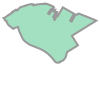

In [6]:
wlds_semb_plan_areas.iloc[0].geometry

<Axes: >

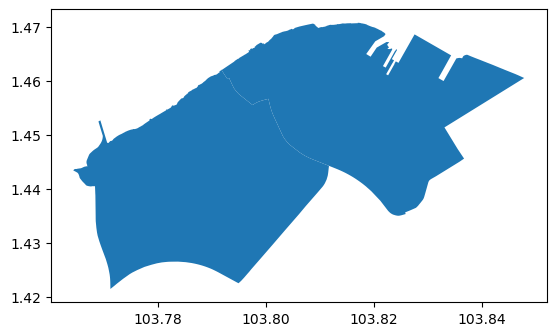

In [7]:
wlds_semb_plan_areas.plot()

In [8]:
# Reproject to SVY21
wlds_semb_plan_areas

,geometry,OBJECTID,SUBZONE_NO,SUBZONE_N,SUBZONE_C,CA_IND,PLN_AREA_C,REGION_N,REGION_C,INC_CRC,FMEL_UPD_D,SHAPE.AREA,SHAPE.LEN
PLN_AREA_N,,,,,,,,,,,,,
SEMBAWANG,"POLYGON ((103.83039 1.44169, 103.83031 1.44163...",938,3,SEMBAWANG CENTRAL,SBSZ03,N,SB,NORTH REGION,NR,5FDC3CA8CAC33369,20191223152313,9.614217e+05,3950.533597
WOODLANDS,"POLYGON ((103.78253 1.42655, 103.78205 1.42654...",937,3,WOODLANDS EAST,WDSZ03,N,WD,NORTH REGION,NR,C90769E43EE6B0F2,20191223152313,2.553464e+06,6603.608301


In [9]:
wlds_semb_plan_areas_svy21 = wlds_semb_plan_areas.to_crs(epsg=3414)

In [10]:
# Original projection is 4326
wlds_semb_sizes_df = pd.DataFrame(wlds_semb_plan_areas_svy21.area).reset_index().rename(
    columns={'PLN_AREA_N':'planning_area_name',
             0: 'area'})

# Convert area from metres to km^2
wlds_semb_sizes_df['area'] = wlds_semb_sizes_df['area'].apply(lambda area: area/10**6)

print(f"Total size of Sembawang and Woodlands is {sum(wlds_semb_sizes_df['area'])} km^2.")

Total size of Sembawang and Woodlands is 26.248709284372953 km^2.


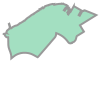

In [11]:
wlds_semb_polygon = wlds_semb_plan_areas.dissolve(by="REGION_C").reset_index()['geometry'][0]
wlds_semb_polygon

## Woodlands-Sembawang Network to GDF

In [ ]:
# Def abstract function to convert to network

In [49]:
wlds_semb_road_network_nodes, wlds_semb_road_network_edges = ox.graph_to_gdfs(wlds_semb_road_network)
wlds_semb_road_network_nodes = wlds_semb_road_network_nodes.reset_index()
wlds_semb_road_network_edges = wlds_semb_road_network_edges.reset_index()

In [50]:
wlds_semb_bike_network_nodes, wlds_semb_bike_network_edges = ox.graph_to_gdfs(wlds_semb_bike_network)
wlds_semb_bike_network_nodes = wlds_semb_bike_network_nodes.reset_index()
wlds_semb_bike_network_edges = wlds_semb_bike_network_edges.reset_index()

In [51]:
wlds_semb_road_network_edges.head(2)

,u,v,key,osmid,highway,lanes,maxspeed,name,oneway,ref,reversed,length,bridge,geometry,access,tunnel,junction
0,157992135,157992392,0,"[75402226, 134996389, 75402231]",motorway,3,90,Bukit Timah Expressway,True,BKE,False,1068.778036,yes,"LINESTRING (103.76865 1.43614, 103.76864 1.435...",NaN,NaN,NaN
1,157992392,1110672133,0,"[649587049, 633797884]",motorway,"[3, 4]",90,Bukit Timah Expressway,True,BKE,False,181.138111,NaN,"LINESTRING (103.77058 1.42682, 103.77086 1.425...",NaN,NaN,NaN


In [52]:
wlds_semb_road_line_strings = [line_strings for line_strings in wlds_semb_road_network_edges['geometry']]

In [53]:
wlds_semb_bike_line_strings = [line_strings for line_strings in wlds_semb_bike_network_edges['geometry']]

In [54]:
def reverse_coords_in_list(coords_list):
    reversed_coords_list = [(y,x) for (x,y) in coords_list]
    return reversed_coords_list

In [105]:
map = folium.Map(location=[1.37529, 103.80465], tiles="CartoDB Positron", zoom_start=11.5)
MousePosition().add_to(map)

for line_string in wlds_semb_road_line_strings:
    coordinates = reverse_coords_in_list(list(line_string.coords))
    folium.PolyLine(
        locations=coordinates,
        color="red",
        weight=5,
        tooltip="Road",
    ).add_to(map)

for line_string in wlds_semb_bike_line_strings:
    coordinates = reverse_coords_in_list(list(line_string.coords))
    folium.PolyLine(
        locations=coordinates,
        color="green",
        weight=2,
        tooltip="Bike",
        opacity=0.5,
    ).add_to(map)

folium.LayerControl().add_to(map)
map.save("./maps/test_map.html")

In [67]:
wlds_semb_road_network_edges['tooltip_label'] = 'Roads'
wlds_semb_bike_network_edges['tooltip_label'] = 'Bike Path / Sidewalk'

In [ ]:
# Merged multiline map
map = folium.Map(location=[1.37529, 103.80465], tiles="CartoDB Positron", zoom_start=11.5)
MousePosition().add_to(map)

tooltip = folium.GeoJsonTooltip(
    fields=['tooltip_label'],
    aliases=["Network Type:"]
)

folium.GeoJson(wlds_semb_road_network_edges,
               tooltip=tooltip,
               style_function=lambda x : {'color': CONFIG["COLOURS"]['ROADS'],
                                          "weight": CONFIG["WEIGHT"]["ROADS"]}
               ).add_to(map)

tooltip = folium.GeoJsonTooltip(
    fields=['tooltip_label'],
    aliases=["Network Type:"]
)

folium.GeoJson(wlds_semb_bike_network_edges,
               tooltip=tooltip,
               style_function=lambda x : {'color': CONFIG["COLOURS"]['BIKE_PED'],
                                          "weight": CONFIG["WEIGHT"]["BIKE_PED"]}
               ).add_to(map)

folium.LayerControl().add_to(map)

map.save("./maps/merged_lines_map_trial.html")


NameError: name 'wlds_semb_road_network_edges' is not defined

In [83]:
type(wlds_semb_bike_network_edges)

geopandas.geodataframe.GeoDataFrame

In [101]:
difference_network = wlds_semb_bike_network_edges['geometry'].difference(wlds_semb_road_network_edges['geometry'])
difference_network_gpd = gpd.GeoDataFrame(difference_network)
difference_network_gpd['tooltip_label'] = 'Difference'

difference_network_gpd = difference_network_gpd.rename(columns={
    0: 'geometry'
})
difference_network_gpd = difference_network_gpd.set_geometry("geometry")
difference_network_gpd = difference_network_gpd[
    (difference_network_gpd.geometry.notnull()) & 
    (~difference_network_gpd.geometry.is_empty)
]

# Merged multiline map
map = folium.Map(location=[1.37529, 103.80465], tiles="CartoDB Positron", zoom_start=11.5)
MousePosition().add_to(map)

tooltip = folium.GeoJsonTooltip(
    fields=['tooltip_label'],
    aliases=["Network Type:"]
)

folium.GeoJson(difference_network_gpd,
               tooltip=tooltip,
               ).add_to(map)


map.save("./maps/diff_map.html")

/tmp/ipykernel_51202/2028113101.py:1: UserWarning: The indices of the left and right GeoSeries' are not equal, and therefore they will be aligned (reordering and/or introducing missing values) before executing the operation. If this alignment is the desired behaviour, you can silence this warning by passing 'align=True'. If you don't want alignment and protect yourself of accidentally aligning, you can pass 'align=False'.
  difference_network = wlds_semb_bike_network_edges['geometry'].difference(wlds_semb_road_network_edges['geometry'])
/home/nicholas/miniconda3/envs/ox/lib/python3.14/site-packages/geopandas/geoseries.py:906: UserWarning: GeoSeries.notna() previously returned False for both missing (None) and empty geometries. Now, it only returns False for missing values. Since the calling GeoSeries contains empty geometries, the result has changed compared to previous versions of GeoPandas.
Given a GeoSeries 's', you can use '~s.is_empty & s.notna()' to get back the old behaviour.

T

In [99]:
# Merged multiline map
map = folium.Map(location=[1.37529, 103.80465], tiles="CartoDB Positron", zoom_start=11.5)
MousePosition().add_to(map)

tooltip = folium.GeoJsonTooltip(
    fields=['tooltip_label'],
    aliases=["Network Type:"]
)

folium.GeoJson(difference_network_gpd,
               tooltip=tooltip,
               ).add_to(map)


map.save("./maps/diff_map.html")

ValueError: Cannot render objects with any missing geometries:                                                geometry tooltip_label
0     LINESTRING (103.76869 1.44104, 103.76878 1.441...    Difference
1     LINESTRING (103.82582 1.43542, 103.82579 1.435...    Difference
2     LINESTRING (103.82357 1.44483, 103.82354 1.44496)    Difference
3     LINESTRING (103.82357 1.44483, 103.82349 1.444...    Difference
4     LINESTRING (103.82354 1.44496, 103.82364 1.44503)    Difference
...                                                 ...           ...
2590  LINESTRING (103.77307 1.43202, 103.77297 1.43207)    Difference
2591  LINESTRING (103.77307 1.43202, 103.77305 1.431...    Difference
2592  LINESTRING (103.77307 1.43202, 103.77314 1.431...    Difference
2593  LINESTRING (103.78796 1.43201, 103.78791 1.43205)    Difference
2594  LINESTRING (103.78796 1.43201, 103.78787 1.431...    Difference

[2595 rows x 2 columns]

## Merging Polylines into one

In [11]:
woodlands_network_nodes, woodlands_network_edges = network_to_gdf(G_sg_woodlands_roads)
woodlands_network_edges = list(woodlands_network_edges['geometry'])

In [30]:
shapely.ops.linemerge(woodlands_network_edges).geoms[0].coords

[(103.7670499, 1.4449728),
 (103.7670919, 1.444974),
 (103.7671831, 1.4449816),
 (103.767212, 1.4450534)]

In [ ]:
# Singapore SBS map
# Side-by-side
# Left: map_delft_diff 
# Right: map_delft

# Create markers
feature_group = folium.FeatureGroup("Intersections")
# delft_markers = [[51.98905, 4.35883, "Intersection"]]

# for marker in delft_markers:
#     lat, lon, name = marker
#     feature_group.add_child(folium.Marker(location=[lat,lon],popup=name))



# Create map
sbs_delft_map = folium.plugins.DualMap(location=[52.01, 4.365], tiles="CartoDB Positron", zoom_start=12)
MousePosition().add_to(sbs_delft_map)
sbs_delft_map.add_child(feature_group)

SMOOTH_FACTOR = 5
tile = folium.TileLayer(
        tiles = 'https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
        attr = 'Esri',
        name = 'Esri Satellite',
        overlay = False,
        control = True
       ).add_to(sbs_delft_map.m1)

folium.GeoJson(delft_road_edges_gdf,
                name="Roads Network",
                smooth_factor=SMOOTH_FACTOR
                ).add_to(sbs_delft_map.m1)

folium.GeoJson(delft_bike_edges_gdf,
               style_function=lambda feature: {'color': CONFIG["network_colors"]['roads'] if "Roads" in feature["properties"]["tooltip_label"]
                                            else CONFIG["network_colors"]['bike_ped'],
                                          "weight": CONFIG["network_weights"]['roads'] if "Roads" in feature["properties"]["tooltip_label"]
                                            else CONFIG["network_weights"]['bike_ped']},
               name="Bike/Pedestrian Network",
               smooth_factor=SMOOTH_FACTOR
               ).add_to(sbs_delft_map.m2)


folium.GeoJson(delft_road_edges_gdf,
               style_function=lambda feature: {'color': CONFIG["network_colors"]['roads'] if "Roads" in feature["properties"]["tooltip_label"]
                                            else CONFIG["network_colors"]['bike_ped'],
                                          "weight": CONFIG["network_weights"]['roads'] if "Roads" in feature["properties"]["tooltip_label"]
                                            else CONFIG["network_weights"]['bike_ped']},
               name="Roads Network",
               smooth_factor=SMOOTH_FACTOR
               ).add_to(sbs_delft_map.m2)

# sbs = folium.plugins.SideBySideLayers(layer_left=layer_left, layer_right=layer_right)
folium.LayerControl(collapsed=False).add_to(sbs_delft_map)
# layer_left.add_to(sbs_delft_map)
# layer_right.add_to(sbs_delft_map)

sbs_delft_map.save("./maps/sbs_delft.html")

# Netherlands (Delft)

In [5]:
# Side-by-side
# Left: map_delft_diff 
# Right: map_delft

# Create markers
feature_group = folium.FeatureGroup("Markers")
delft_markers = [[51.98905, 4.35883, "Intersection"], 
                 [52.007549429541996, 4.35639517116439, "Delft Train Station"],
                 [52.00369, 4.35679, "Intersection 2"]]

for marker in delft_markers:
    lat, lon, name = marker
    feature_group.add_child(folium.Marker(location=[lat,lon],popup=name))



# Create map
sbs_delft_map = folium.plugins.DualMap(location=[52.01, 4.365], tiles="CartoDB Positron", zoom_start=12)
MousePosition().add_to(sbs_delft_map)
sbs_delft_map.add_child(feature_group)

SMOOTH_FACTOR = 5
tile = folium.TileLayer(
        tiles = 'https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
        attr = 'Esri',
        name = 'Esri Satellite',
        overlay = False,
        control = True
       ).add_to(sbs_delft_map.m1)

folium.GeoJson(delft_road_edges_gdf,
                name="Roads Network",
                smooth_factor=SMOOTH_FACTOR
                ).add_to(sbs_delft_map.m1)

folium.GeoJson(delft_bike_edges_gdf,
               style_function=lambda feature: {'color': CONFIG["network_colors"]['roads'] if "Roads" in feature["properties"]["tooltip_label"]
                                            else CONFIG["network_colors"]['bike_ped'],
                                          "weight": CONFIG["network_weights"]['roads'] if "Roads" in feature["properties"]["tooltip_label"]
                                            else CONFIG["network_weights"]['bike_ped']},
               name="Bike/Pedestrian Network",
               smooth_factor=SMOOTH_FACTOR
               ).add_to(sbs_delft_map.m2)


folium.GeoJson(delft_road_edges_gdf,
               style_function=lambda feature: {'color': CONFIG["network_colors"]['roads'] if "Roads" in feature["properties"]["tooltip_label"]
                                            else CONFIG["network_colors"]['bike_ped'],
                                          "weight": CONFIG["network_weights"]['roads'] if "Roads" in feature["properties"]["tooltip_label"]
                                            else CONFIG["network_weights"]['bike_ped']},
               name="Roads Network",
               smooth_factor=SMOOTH_FACTOR
               ).add_to(sbs_delft_map.m2)

# sbs = folium.plugins.SideBySideLayers(layer_left=layer_left, layer_right=layer_right)
folium.LayerControl(collapsed=False).add_to(sbs_delft_map)
# layer_left.add_to(sbs_delft_map)
# layer_right.add_to(sbs_delft_map)

sbs_delft_map.save("./maps/sbs_delft.html")

# STOPPED HERE: Delft Intersection W/ Map Bounds

In [4]:
# x_min = The x value of the top left corner of the box.
# y_min = The y value of the top left corner of the box.
# x_max = The x value of the bottom right corner of the box.
# y_max = The y value of the bottom right corner of the box.

delft_corner_points = [(52.02853, 4.32329),
                       (52.03001, 4.37788),
                       (51.96398, 4.32741),
                       (51.96578, 4.40603)]

def get_bb_from_corner_pts(corner_pts, lat_lon=True):
    """
    corner_pts: list of 4 corner points in the format (y, x) or (lat, lon)
    """
    x_vals = [x for (y, x) in corner_pts]
    y_vals = [y for (y, x) in corner_pts]
    x_min = min(x_vals)
    x_max = max(x_vals)
    y_min = min(y_vals)
    y_max = max(y_vals)
    if lat_lon:
        bb_dict = {"top_right": (y_max, x_max),
                   "bottom_right": (y_min, x_max),
                   "bottom_left": (y_min, x_max),
                   "top_left": (y_max, x_min),
                   "min_lat": y_min,
                   "max_lat": y_max,
                   "min_lon": x_min,
                   "max_lon": x_max}
    else:
        bb_dict = {"top_right": (x_max, y_max),
                   "bottom_right": (x_max, y_min),
                   "bottom_left": (x_max, y_min),
                   "top_left": (x_min, y_max),
                   "min_lat": y_min,
                   "max_lat": y_max,
                   "min_lon": x_min,
                   "max_lon": x_max}
    return bb_dict

get_bb_from_corner_pts(delft_corner_points)

{'top_right': (52.03001, 4.40603),
 'bottom_right': (51.96398, 4.40603),
 'bottom_left': (51.96398, 4.40603),
 'top_left': (52.03001, 4.32329),
 'min_lat': 51.96398,
 'max_lat': 52.03001,
 'min_lon': 4.32329,
 'max_lon': 4.40603}

## Make map faster...

In [12]:
# Inspect underlying geodata to understand why there is rendering lag
# Geojsons to modify
# 1. delft_road_edges_gdf
# 2. delft_bike_edges_gdf
type(delft_road_edges_gdf)
delft_road_edges_topojson = tp.Topology(delft_road_edges_gdf, prequantize=False).to_json()
# Attempt: Convert geojson to topojson
# delft_road_edges_gdf.head()

In [16]:
delft_road_edges_topojson

'{"type":"Topology","objects":{"data":{"geometries":[{"properties":{"u":27082148,"v":44839614,"key":0,"osmid":48688450,"highway":"tertiary","lanes":"2","maxspeed":"50","name":"Delfgauwseweg","oneway":false,"reversed":false,"length":141.0114547365335,"tunnel":NaN,"bridge":NaN,"access":NaN,"ref":NaN,"width":NaN,"junction":NaN,"tooltip_label":"Roads"},"type":"LineString","arcs":[440],"id":0},{"properties":{"u":27082148,"v":44835830,"key":0,"osmid":7537370,"highway":"residential","lanes":NaN,"maxspeed":"30","name":"Spiekmanstraat","oneway":false,"reversed":true,"length":39.82140294580047,"tunnel":NaN,"bridge":NaN,"access":NaN,"ref":NaN,"width":NaN,"junction":NaN,"tooltip_label":"Roads"},"type":"LineString","arcs":[403],"id":1},{"properties":{"u":27082148,"v":44833192,"key":0,"osmid":48688450,"highway":"tertiary","lanes":"2","maxspeed":"50","name":"Delfgauwseweg","oneway":false,"reversed":true,"length":124.18055332221716,"tunnel":NaN,"bridge":NaN,"access":NaN,"ref":NaN,"width":NaN,"junction

In [15]:
# Side-by-side (Copied code above TODO: Modify with map bounds)
# Left: map_delft_diff 
# Right: map_delft
# https://python-visualization.github.io/folium/latest/user_guide/map.html <-
# Create markers

feature_group = folium.FeatureGroup("Markers")
delft_markers = [[51.98905, 4.35883, "Intersection"], 
                 [52.007549429541996, 4.35639517116439, "Delft Train Station"],
                 [52.00369, 4.35679, "Intersection 2"]]

for marker in delft_markers:
    lat, lon, name = marker
    feature_group.add_child(folium.Marker(location=[lat,lon],popup=name))


bb_dict = get_bb_from_corner_pts(delft_corner_points)

# Create map
# Issue: prefer_canvas gives misaligned lines when you move the map position
sbs_delft_map = folium.plugins.DualMap(location=[51.98905, 4.35883], tiles="CartoDB Positron", 
                                       zoom_start=18,
                                    #    prefer_canvas=True,
                                       max_bounds=True,
                                       min_lat = bb_dict['min_lat'],
                                       max_lat = bb_dict['max_lat'],
                                       min_lon = bb_dict['min_lon'],
                                       max_lon = bb_dict['max_lon'])
MousePosition().add_to(sbs_delft_map)
sbs_delft_map.add_child(feature_group)

SMOOTH_FACTOR = 5
tile = folium.TileLayer(
        tiles = 'https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
        attr = 'Esri',
        name = 'Esri Satellite',
        overlay = False,
        control = True
       ).add_to(sbs_delft_map.m1)

folium.GeoJson(delft_road_edges_topojson,
                name="Roads Network",
                smooth_factor=SMOOTH_FACTOR
                ).add_to(sbs_delft_map.m1)

folium.GeoJson(delft_bike_edges_gdf,
               style_function=lambda feature: {'color': CONFIG["network_colors"]['roads'] if "Roads" in feature["properties"]["tooltip_label"]
                                            else CONFIG["network_colors"]['bike_ped'],
                                          "weight": CONFIG["network_weights"]['roads'] if "Roads" in feature["properties"]["tooltip_label"]
                                            else CONFIG["network_weights"]['bike_ped']},
               name="Bike/Pedestrian Network",
               smooth_factor=SMOOTH_FACTOR
               ).add_to(sbs_delft_map.m2)


folium.GeoJson(delft_road_edges_gdf,
               style_function=lambda feature: {'color': CONFIG["network_colors"]['roads'] if "Roads" in feature["properties"]["tooltip_label"]
                                            else CONFIG["network_colors"]['bike_ped'],
                                          "weight": CONFIG["network_weights"]['roads'] if "Roads" in feature["properties"]["tooltip_label"]
                                            else CONFIG["network_weights"]['bike_ped']},
               name="Roads Network",
               smooth_factor=SMOOTH_FACTOR
               ).add_to(sbs_delft_map.m2)

# sbs = folium.plugins.SideBySideLayers(layer_left=layer_left, layer_right=layer_right)
folium.LayerControl(collapsed=False).add_to(sbs_delft_map)
# layer_left.add_to(sbs_delft_map)
# layer_right.add_to(sbs_delft_map)

sbs_delft_map.save("./maps/sbs_delft_intersection.html")

In [41]:
delft_road_network = ox.graph.graph_from_place("Delft, Netherlands", network_type="drive")

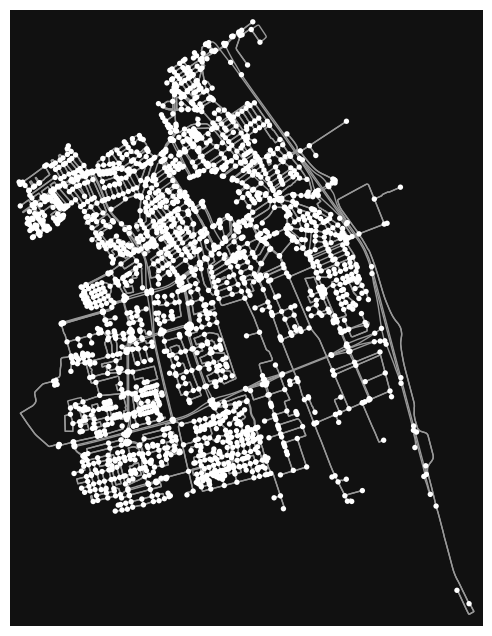

In [43]:
fig, ax = ox.plot.plot_graph(delft_road_network)

In [42]:
delft_bike_network = ox.graph.graph_from_place("Delft, Netherlands", network_type="bike")

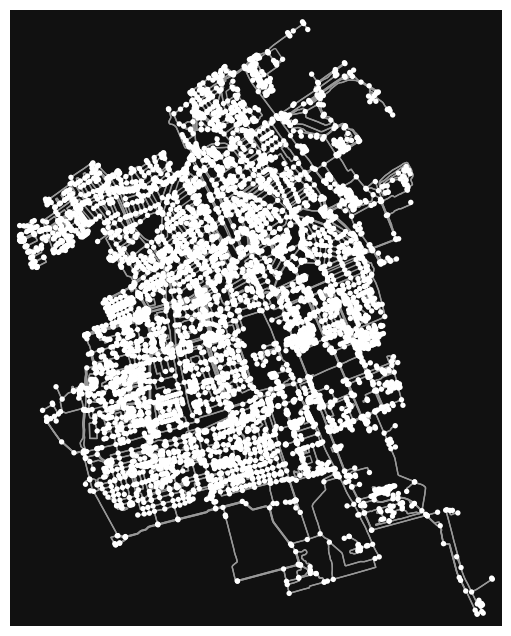

In [ ]:
fig, ax = ox.plot.plot_graph(delft_bike_network)

In [116]:
delft_road_network_nodes, delft_road_network_edges = network_to_gdf(delft_road_network)
delft_bike_network_nodes, delft_bike_network_edges = network_to_gdf(delft_bike_network)

In [117]:
delft_road_line_strings = gdf_to_line_string_list(delft_road_network_edges)
delft_bike_line_strings = gdf_to_line_string_list(delft_bike_network_edges)

In [119]:
map_delft = folium.Map(location=[52.01, 4.36], tiles="CartoDB Positron", zoom_start=11.5)
MousePosition().add_to(map_delft)

for line_string in delft_road_line_strings:
    coordinates = reverse_coords_in_list(list(line_string.coords))
    folium.PolyLine(
        locations=coordinates,
        color="red",
        weight=5,
        tooltip="Road",
    ).add_to(map_delft)

for line_string in delft_bike_line_strings:
    coordinates = reverse_coords_in_list(list(line_string.coords))
    folium.PolyLine(
        locations=coordinates,
        color="green",
        weight=2,
        tooltip="Bike",
        opacity=0.5,
    ).add_to(map_delft)

folium.LayerControl().add_to(map_delft)
map_delft.save("./maps/deflt.html")